### 2. Загрузка данных

0.6033333333333334
0.39666666666666667
0.39431983870392845
0.37835339696908743
1.1510266326421033
0.6022860728015621
0.5487405598405412
0
0
0.21528264430317182
0.21528264430317182
1.1510266326421033
0.7168141592920354
0.25663716814159293
0.224954333283238
0.675700674593428
1.576355682470094
0.1982405885057642
0.22540372902414174
0.6290888528941371
0.08888481996107055
0.2227254391591376
0.3116102591202081
2.205444535364231
0.690000
0.310000
0.278814
0.588567
1.455948
0.251478
0.292575
0.291282
0.117249
0.228478
0.274188
1.747229


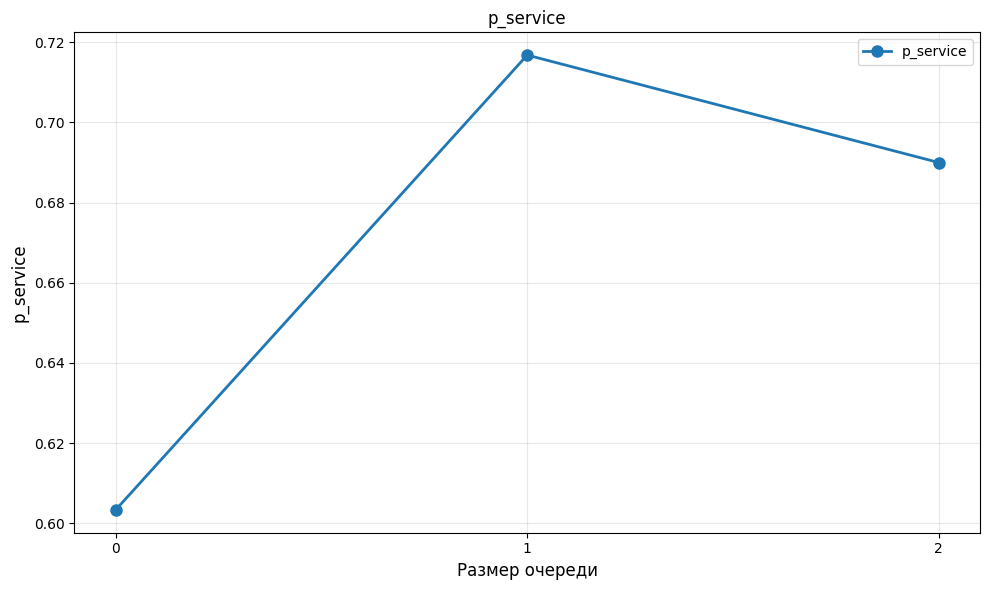

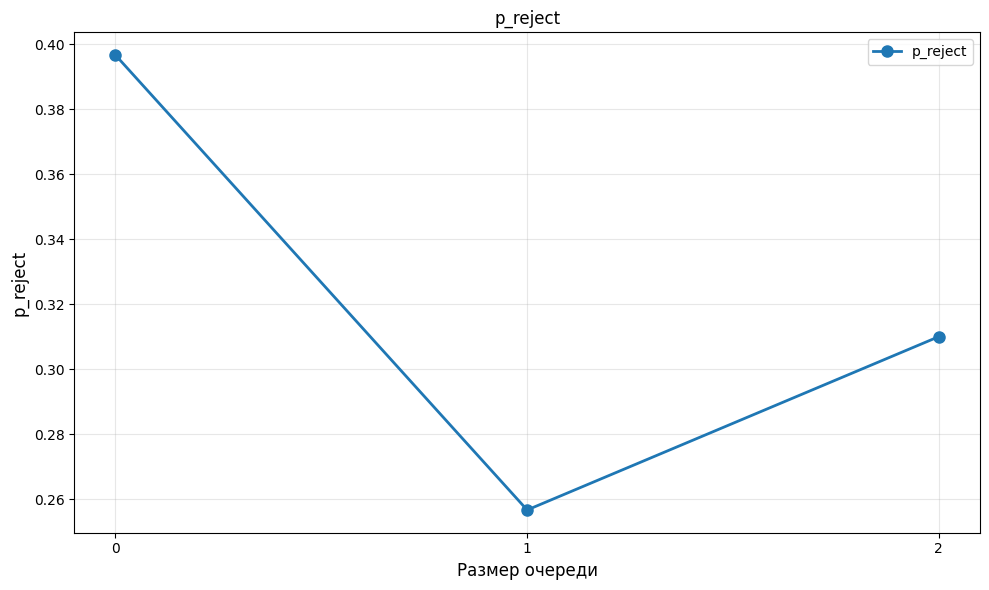

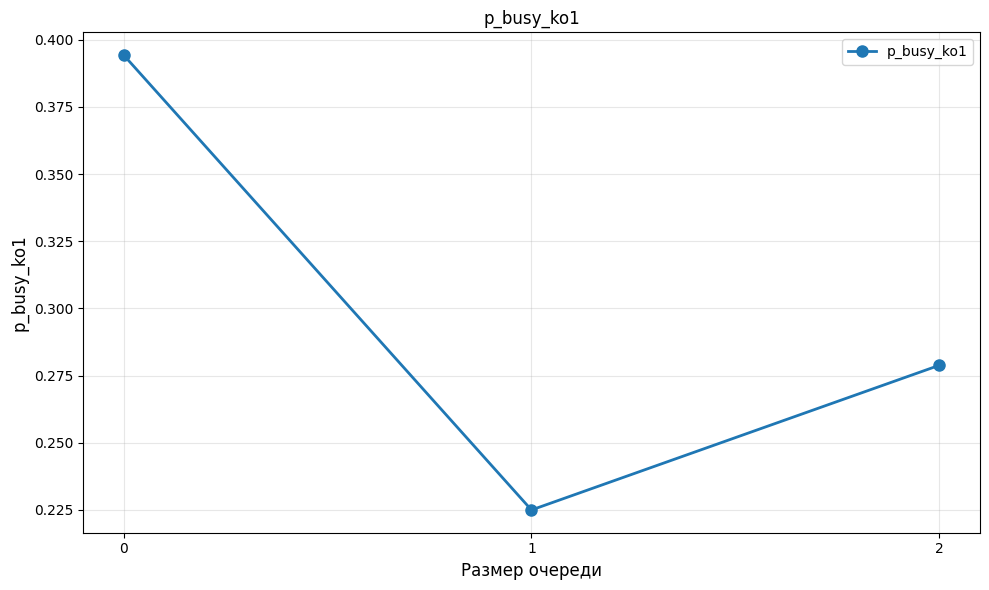

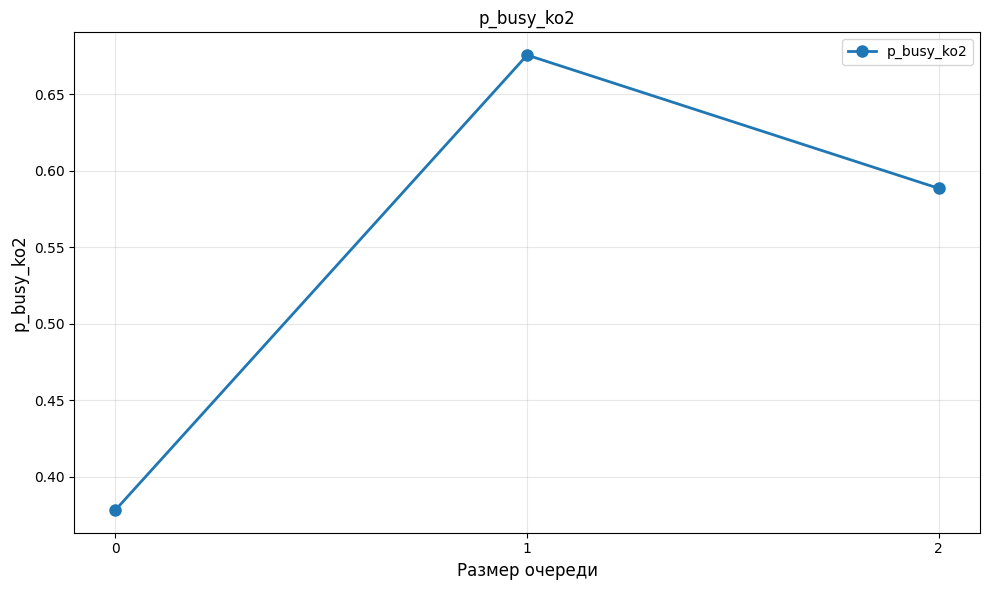

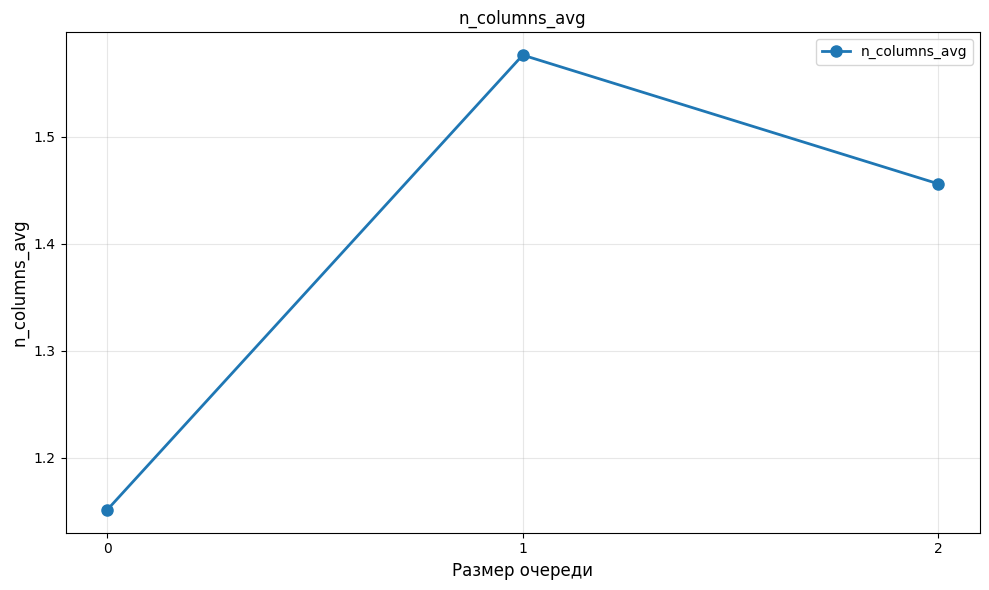

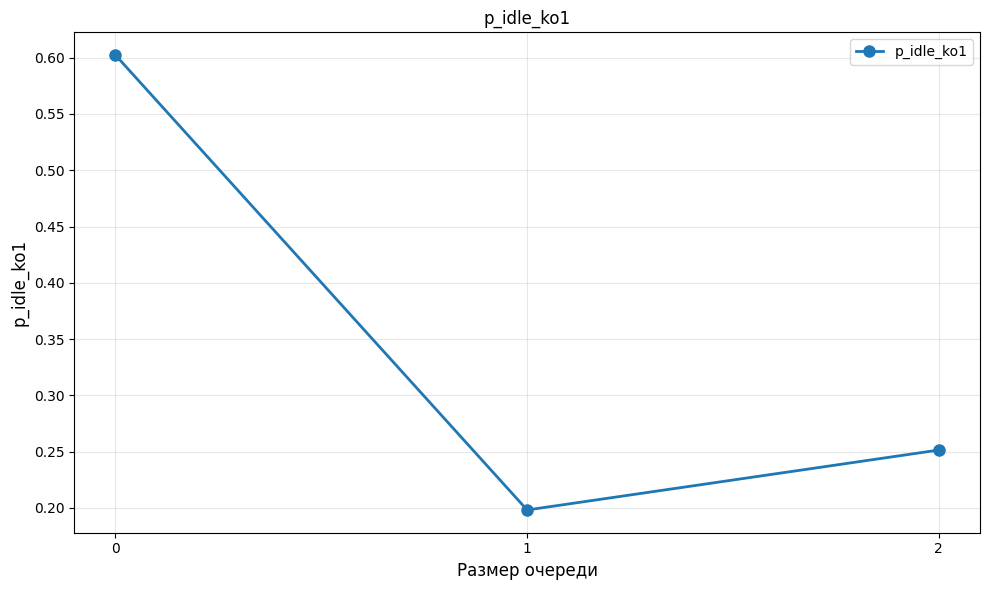

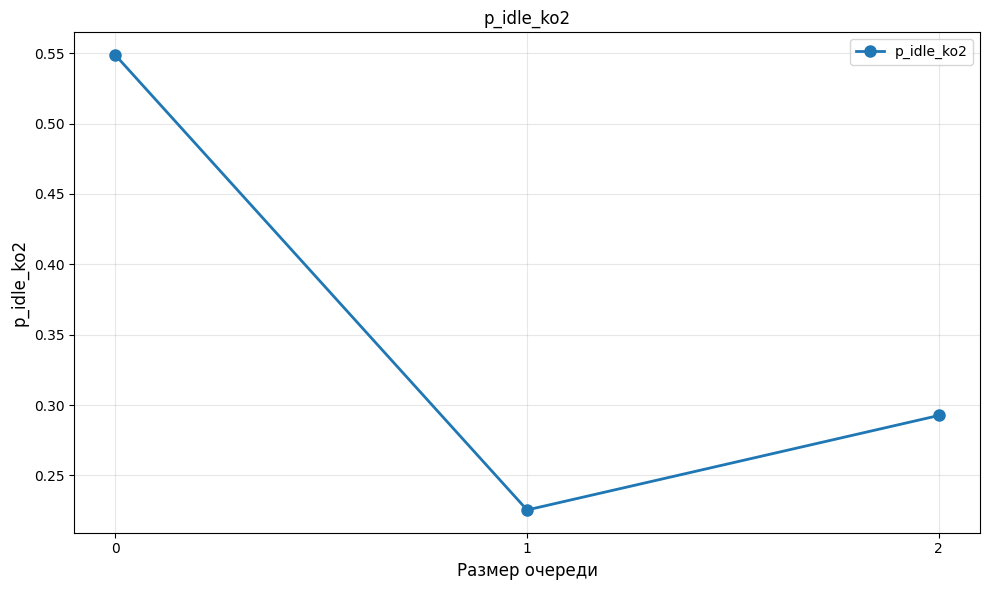

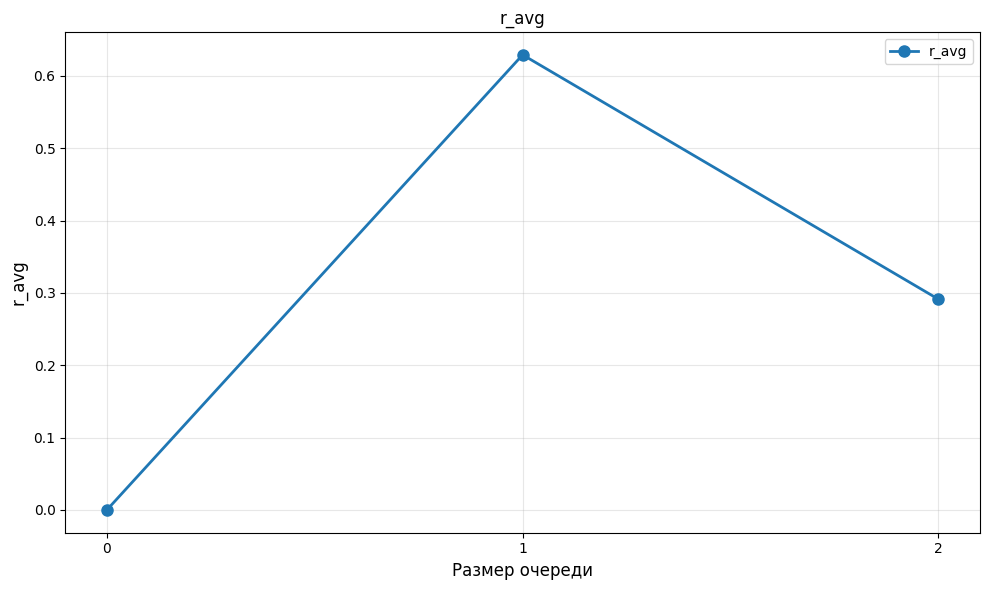

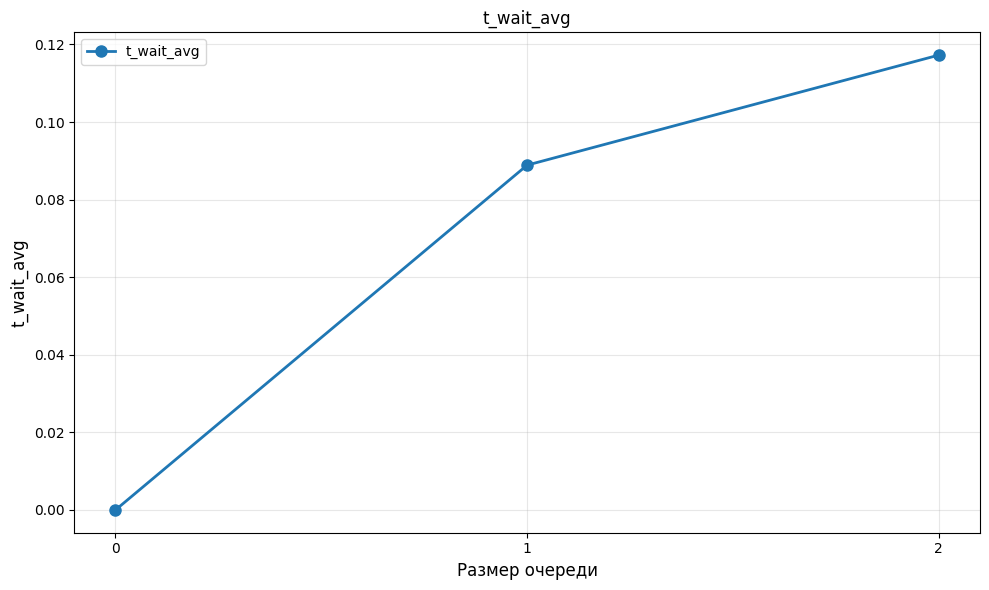

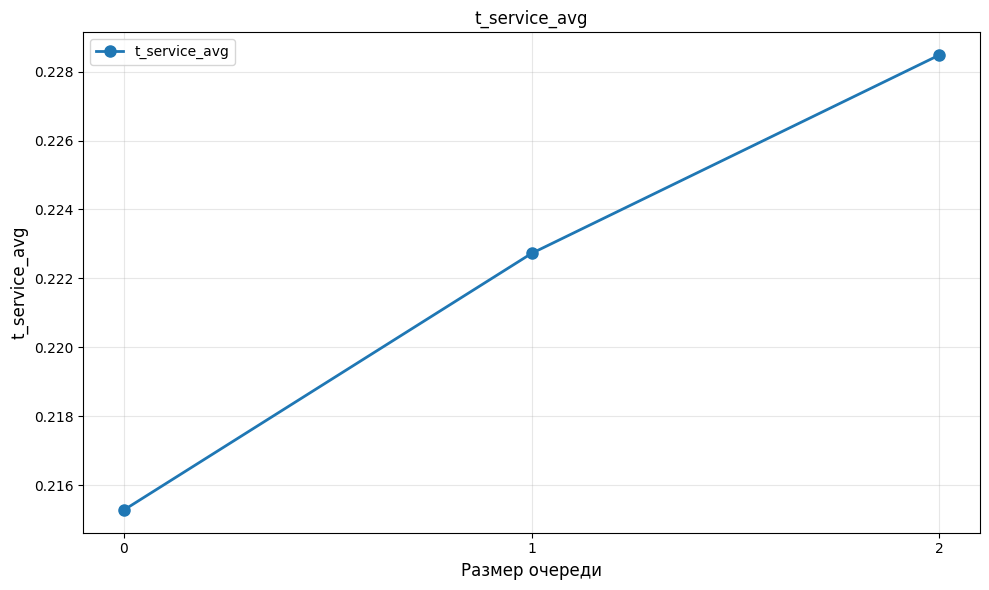

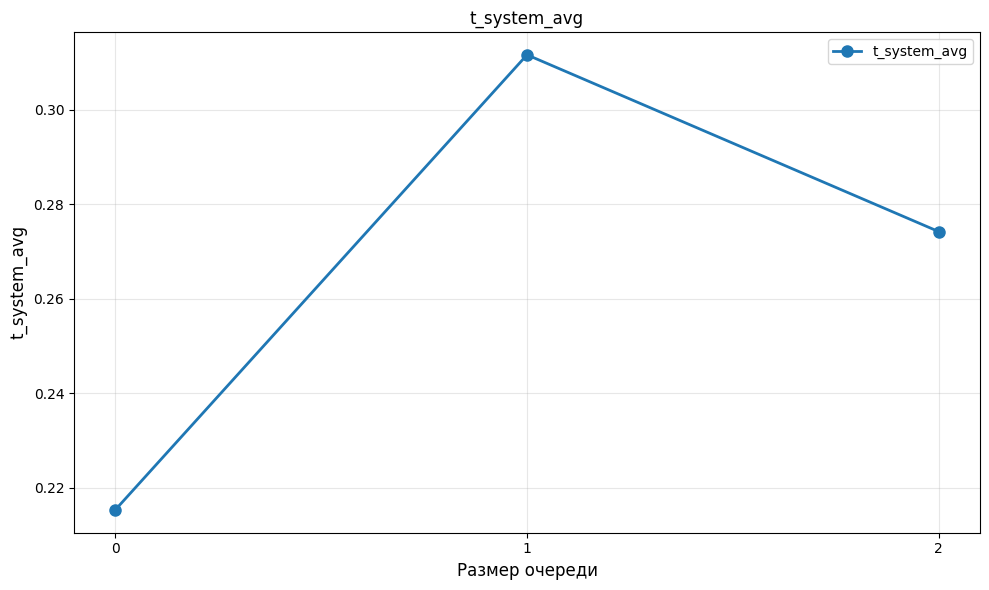

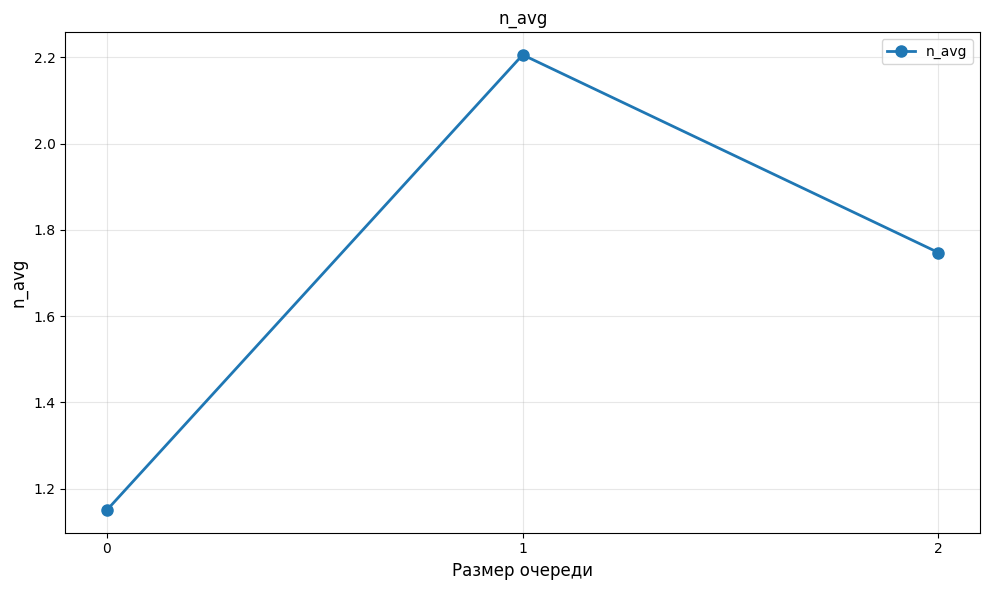

In [1]:
import csv
import matplotlib.pyplot as plt
from pathlib import Path

FILENAME = "results.csv"
BASE_DIR = Path.cwd()

def find_all_csv_files(base_dir, filename):
    found_files = []
    for path in base_dir.rglob(filename):
        if '.git' not in str(path):
            found_files.append(path)
    return found_files

def get_data_csv(path):
    if not path.exists():
        print("Файл не найден")
        return {}
    try:
        with open(path, "r", newline="", encoding="utf-8") as file:
            reader = csv.reader(file)
            next(reader)
            return {row[0]: row[1] for row in reader}
    except Exception as e:
        print(f"Ошибка работы с файлом {path}. {e}")
        return {}

# Ищем все results.csv
all_files = find_all_csv_files(BASE_DIR, FILENAME)

# Собираем данные
data = {}
for file_path in all_files:
    data_queue = get_data_csv(file_path)
    for key, value in data_queue.items():
        print(value)
        value = float(value)
        data[key] = [value] if key not in data else data[key] + [value]

# Построение графиков по одному (прежний формат)
for key, value in data.items():
    plt.figure(figsize=(10, 6))
    plt.title(key)
    plt.plot(value, marker='o', linewidth=2, markersize=8, label=key)
    plt.xlabel('Размер очереди', fontsize=12)
    plt.ylabel(key, fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks([0, 1, 2], ['0', '1', '2'])
    plt.legend()
    plt.tight_layout()
    plt.show()